# NIH Reporter Grant & Publication Fetcher

This notebook reads grant numbers from a CSV file, queries the [NIH Reporter API](https://api.reporter.nih.gov/) for grant details and associated publications, and saves the results to Excel.

**API used:** `https://api.reporter.nih.gov/v2/` (no API key required)

In [36]:
# Uncomment if needed:
# !pip install requests pandas openpyxl tqdm

import requests
import pandas as pd
import time
import json
from tqdm.notebook import tqdm
from pathlib import Path

import os
print(os.getcwd())
print(os.listdir())

C:\Users\keg827\Documents\Github_Repos\FSM_NIH Reporter T32 Gap Analysis
['.ipynb_checkpoints', 'data', 'NIA_T32_Landscape_Analysis.ipynb', 'output']


In [33]:
# ── USER SETTINGS ──────────────────────────────────────────────────────────────
CSV_PATH        = "data/grants.csv"          # Path to your input CSV
GRANT_COL       = "Project Number"        # Column name containing grant numbers
OUTPUT_FILE     = "output/nih_results.xlsx"    # Output Excel file
DELAY_SECONDS   = 0.5                   # Pause between API calls (be polite)
PAGE_SIZE       = 500                   # Max records per page (API limit is 500)
# ───────────────────────────────────────────────────────────────────────────────

BASE_URL = "https://api.reporter.nih.gov/v2"
HEADERS  = {"Content-Type": "application/json", "accept": "application/json"}

In [34]:
## Load grant numbers from csv

df_input = pd.read_csv(CSV_PATH)
print(f"Columns found: {df_input.columns.tolist()}")
print(f"Rows: {len(df_input)}")
df_input.head()

Columns found: ['Project Number']
Rows: 46


,Project Number
0,T32AG078114
1,T32AG049688
2,T32AG049663
3,T32AG047126
4,T32AG021890


In [4]:
# Clean up grant numbers: strip whitespace, drop blanks, deduplicate
grant_numbers = (
    df_input[GRANT_COL]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .drop_duplicates()
    .tolist()
)

print(f"Unique grant numbers to query: {len(grant_numbers)}")
print(grant_numbers[:5])

Unique grant numbers to query: 44
['T32AG078114', 'T32AG049688', 'T32AG049663', 'T32AG047126', 'T32AG021890']


In [5]:
def fetch_grant_info(grant_number: str) -> list[dict]:
    """
    Query NIH Reporter for a single grant number.
    Paginates to retrieve ALL fiscal years (each has its own appl_id).
    """
    url = f"{BASE_URL}/projects/search"
    all_records = []
    offset = 0

    while True:
        payload = {
            "criteria": {"project_nums": [grant_number]},
            "offset": offset,
            "limit": PAGE_SIZE,
            "fields": [
                "project_num", "project_title", "fiscal_year",
                "project_start_date", "project_end_date", "award_amount",
                "agency_ic_admin", "organization", "principal_investigators",
                "program_officers", "abstract_text", "activity_code",
                "award_type", "full_study_section", "is_active", "appl_id"
            ]
        }
        try:
            resp = requests.post(url, headers=HEADERS, json=payload, timeout=30)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"  WARNING: Error fetching grant {grant_number}: {e}")
            break

        page_results = data.get("results", [])
        all_records.extend(page_results)

        total = data.get("total")
        offset += len(page_results)

        if not page_results:
            break
        if total is not None and offset >= total:
            break
        if len(page_results) < PAGE_SIZE:
            # Shorter page means we've hit the end even if total is None
            break

    return all_records


def fetch_publications(appl_id: int, grant_number: str = "") -> list[dict]:
    """
    Fetch publications for one appl_id.
    Since the publications endpoint does not return a reliable total,
    we page until we get a short or empty page.
    """
    url = f"{BASE_URL}/publications/search"
    all_pubs = []
    offset = 0
    page_num = 0

    while True:
        payload = {
            "criteria": {"appl_ids": [appl_id]},
            "offset": offset,
            "limit": PAGE_SIZE
        }
        try:
            resp = requests.post(url, headers=HEADERS, json=payload, timeout=30)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"  WARNING: Error fetching publications for appl_id {appl_id}: {e}")
            break

        page_results = data.get("results", [])
        all_pubs.extend(page_results)
        page_num += 1
        offset += len(page_results)

        if page_num > 1:
            print(f"    {grant_number} appl_id {appl_id}: fetched {offset} publications so far...")

        # Stop on empty or short page (no reliable total available)
        if len(page_results) < PAGE_SIZE:
            break

        time.sleep(DELAY_SECONDS)

    return all_pubs

In [6]:
## Flatten helper function
def flatten_grant(record: dict, queried_grant_num: str) -> dict:
    """Extract key fields from a grant record into a flat dict."""
    org = record.get("organization") or {}
    pis = record.get("principal_investigators") or []
    pi_names = "; ".join(
        f"{p.get('last_name', '')}, {p.get('first_name', '')}".strip(", ")
        for p in pis
    )
    return {
        "queried_grant_number":  queried_grant_num,
        "project_num":           record.get("project_num"),
        "appl_id":               record.get("appl_id"),
        "project_title":         record.get("project_title"),
        "fiscal_year":           record.get("fiscal_year"),
        "project_start_date":    record.get("project_start_date"),
        "project_end_date":      record.get("project_end_date"),
        "is_active":             record.get("is_active"),
        "award_amount":          record.get("award_amount"),
        "activity_code":         record.get("activity_code"),
        "award_type":            record.get("award_type"),
        "agency_ic_admin":       (record.get("agency_ic_admin") or {}).get("abbreviation"),
        "organization_name":     org.get("org_name"),
        "organization_city":     org.get("org_city"),
        "organization_state":    org.get("org_state"),
        "principal_investigators": pi_names,
        "study_section":         (record.get("full_study_section") or {}).get("name"),
        "abstract_text":         record.get("abstract_text"),
    }


def flatten_publication(pub: dict, queried_grant_num: str, appl_id: int) -> dict:
    """Extract key fields from a publication record into a flat dict."""
    return {
        "queried_grant_number": queried_grant_num,
        "appl_id":              appl_id,
        "pmid":                 pub.get("pmid"),
        "title":                pub.get("title"),
        "authors":              pub.get("author_list"),
        "journal":              pub.get("journal_title") or pub.get("journal_title_abbreviation"),
        "pub_date":             pub.get("pub_date"),
        "pub_year":             pub.get("pub_year"),
        "doi":                  pub.get("doi"),
        "pubmed_url":           f"https://pubmed.ncbi.nlm.nih.gov/{pub.get('pmid')}/" if pub.get("pmid") else None,
    }

In [7]:
all_grants = []
all_publications = []
not_found = []

for grant_num in tqdm(grant_numbers, desc="Querying NIH Reporter"):
    # ── Fetch grant info ───────────────────────────────────────────────────────
    records = fetch_grant_info(grant_num)

    if not records:
        not_found.append(grant_num)
        time.sleep(DELAY_SECONDS)
        continue

    appl_ids_seen = set()

    for record in records:
        flat_grant = flatten_grant(record, grant_num)
        all_grants.append(flat_grant)

        appl_id = record.get("appl_id")
        if appl_id and appl_id not in appl_ids_seen:
            appl_ids_seen.add(appl_id)

            # ── Fetch ALL publications for this application (paginated) ─────────
            time.sleep(DELAY_SECONDS)
            pubs = fetch_publications(appl_id, grant_number=grant_num)
            for pub in pubs:
                all_publications.append(flatten_publication(pub, grant_num, appl_id))

    time.sleep(DELAY_SECONDS)

print(f"\nDone!")
print(f"   Grant records collected : {len(all_grants)}")
print(f"   Publication records     : {len(all_publications)}")
if not_found:
    print(f"   Not found in NIH Reporter ({len(not_found)}): {not_found}")

Querying NIH Reporter:   0%|          | 0/44 [00:00<?, ?it/s]

    T32AG049688 appl_id 11407304: fetched 620 publications so far...
    T32AG049663 appl_id 11382776: fetched 687 publications so far...
    T32AG047126 appl_id 11335973: fetched 507 publications so far...
    T32AG021890 appl_id 11335892: fetched 1000 publications so far...
    T32AG021890 appl_id 11335892: fetched 1500 publications so far...
    T32AG021890 appl_id 11335892: fetched 1509 publications so far...
    T32AG000247 appl_id 11335238: fetched 1000 publications so far...
    T32AG000247 appl_id 11335238: fetched 1500 publications so far...
    T32AG000247 appl_id 11335238: fetched 1830 publications so far...
    T32AG019134 appl_id 11334648: fetched 1000 publications so far...
    T32AG019134 appl_id 11334648: fetched 1343 publications so far...
    T32AG049666 appl_id 11174481: fetched 715 publications so far...
    T32AG000221 appl_id 11174401: fetched 951 publications so far...
    T32AG000222 appl_id 11169990: fetched 1000 publications so far...
    T32AG000222 appl_id 1

In [8]:
## Preview Results

df_grants = pd.DataFrame(all_grants)
df_pubs   = pd.DataFrame(all_publications)

print("=== Grant Info ===")
display(df_grants.head())
print(f"\nShape: {df_grants.shape}")

print("\n=== Publications ===")
display(df_pubs.head())
print(f"\nShape: {df_pubs.shape}")

=== Grant Info ===


,queried_grant_number,project_num,appl_id,project_title,fiscal_year,project_start_date,project_end_date,is_active,award_amount,activity_code,award_type,agency_ic_admin,organization_name,organization_city,organization_state,principal_investigators,study_section,abstract_text
0,T32AG078114,3T32AG078114-04S1,11481795,Multidisciplinary Research Training Program in...,2026,2022-08-01T00:00:00,2027-07-31T00:00:00,True,3000,T32,3,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"Billinger, Sandra; Vidoni, Eric",None,PROJECT SUMMARY/ABSTRACT \nThis is a T32 train...
1,T32AG078114,5T32AG078114-04,11168920,Multidisciplinary Research Training Program in...,2025,2022-08-01T00:00:00,2027-07-31T00:00:00,True,228788,T32,5,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"Billinger, Sandra; Vidoni, Eric",ZAG1-ZIJ-2(M2),PROJECT SUMMARY/ABSTRACT\n This is a T32 train...
2,T32AG078114,5T32AG078114-03,10894798,Multidisciplinary Research Training Program in...,2024,2022-08-01T00:00:00,2027-07-31T00:00:00,False,317625,T32,5,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"Billinger, Sandra; Vidoni, Eric",ZAG1-ZIJ-2(M2),PROJECT SUMMARY/ABSTRACT\n This is a T32 train...
3,T32AG078114,5T32AG078114-02,10672283,Multidisciplinary Research Training Program in...,2023,2022-08-01T00:00:00,2027-07-31T00:00:00,False,295454,T32,5,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"BURNS, JEFFREY; Billinger, Sandra",ZAG1-ZIJ-2(M2),PROJECT SUMMARY/ABSTRACT\n This is a T32 train...
4,T32AG078114,1T32AG078114-01,10496109,Multidisciplinary Research Training Program in...,2022,2022-08-01T00:00:00,2027-07-31T00:00:00,False,294308,T32,1,NIA,UNIVERSITY OF KANSAS MEDICAL CENTER,KANSAS CITY,KS,"BURNS, JEFFREY; Billinger, Sandra",Special Emphasis Panel[ZAG1 ZIJ-2 (M2)],PROJECT SUMMARY/ABSTRACT\n This is a T32 train...



Shape: (602, 18)

=== Publications ===


,queried_grant_number,appl_id,pmid,title,authors,journal,pub_date,pub_year,doi,pubmed_url
0,T32AG078114,11481795,39132486,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/39132486/
1,T32AG078114,11481795,40568661,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/40568661/
2,T32AG078114,11481795,40727873,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/40727873/
3,T32AG078114,11481795,39236780,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/39236780/
4,T32AG078114,11481795,39376152,None,None,None,None,None,None,https://pubmed.ncbi.nlm.nih.gov/39376152/



Shape: (22306, 10)


In [9]:
## Save to Excel

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    df_grants.to_excel(writer, sheet_name="Grant Info",    index=False)
    df_pubs.to_excel(  writer, sheet_name="Publications",  index=False)

    if not_found:
        pd.DataFrame({"grant_number_not_found": not_found}).to_excel(
            writer, sheet_name="Not Found", index=False
        )

print(f"💾 Saved to: {Path(OUTPUT_FILE).resolve()}")

💾 Saved to: C:\Users\keg827\Documents\Github_Repos\FSM_NIH Reporter T32 Gap Analysis\output\nih_results.xlsx


In [10]:
if not df_grants.empty:
    print("Grant counts by fiscal year:")
    display(df_grants["fiscal_year"].value_counts().sort_index())

    if "award_amount" in df_grants.columns:
        total = df_grants["award_amount"].sum()
        print(f"\nTotal award amount across all records: ${total:,.0f}")

if not df_pubs.empty:
    print(f"\nPublications per grant (top 10):")
    pub_counts = (
        df_pubs.groupby("queried_grant_number")["pmid"]
        .count()
        .sort_values(ascending=False)
        .head(10)
        .rename("pub_count")
    )
    display(pub_counts)
    print("\nNote: any grant still at exactly 500 may indicate a pagination error — check the loop output above.")

Grant counts by fiscal year:


fiscal_year
1985     2
1986     2
1987     4
1988     2
1989     3
1990     3
1991     3
1992     5
1993     5
1994     5
1995     7
1996     7
1997     7
1998     8
1999     8
2000     9
2001     9
2002     9
2003    10
2004    10
2005    11
2006    12
2007    11
2008    13
2009    13
2010    13
2011    12
2012    13
2013    12
2014    15
2015    19
2016    22
2017    35
2018    24
2019    23
2020    27
2021    36
2022    39
2023    44
2024    43
2025    40
2026     7
Name: count, dtype: int64


Total award amount across all records: $196,658,870

Publications per grant (top 10):


queried_grant_number
T32AG000247    1830
T32AG000181    1547
T32AG021890    1509
T32AG000114    1473
T32AG019134    1343
T32AG023481    1259
T32AG000029    1158
T32AG000222    1082
T32AG000221     951
T32AG049676     794
Name: pub_count, dtype: int64


Note: any grant still at exactly 500 may indicate a pagination error — check the loop output above.


# VOSviewer Corpus Preparation

Reads `nih_results.xlsx` (produced by the NIH Reporter query notebook) and generates two plain-text files ready to load directly into VOSviewer for term co-occurrence mapping:

- **`vosviewer_corpus.txt`** — title + abstract per grant (recommended; richer map)
- **`vosviewer_titles.txt`** — titles only (fallback if abstracts are sparse)

Each file has one grant per line, deduplicated so long-running multi-year grants are not over-represented.

In [15]:
## Configuration

import re
import pandas as pd
from pathlib import Path

# ── USER SETTINGS ──────────────────────────────────────────────────────────────
INPUT_FILE  = "output/nih_results.xlsx"   # Path to your NIH Reporter Excel output
SHEET_NAME  = "Grant Info"                # Sheet containing grant data
OUT_DIR     = "output"                    # Folder where corpus files will be saved
# ───────────────────────────────────────────────────────────────────────────────

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

In [19]:
## Load Grant Data

df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME, dtype=str)
print(f"Rows loaded        : {len(df)}")

# Extract core grant number by stripping the leading digit and trailing -XX suffix
# e.g. "5T32AG012345-10" → "T32AG012345"
def core_grant_num(val):
    if not isinstance(val, str):
        return val
    val = val.strip()
    val = re.sub(r"^\d+", "", val)       # remove leading digit (e.g. "5")
    val = re.sub(r"-\d+[A-Z]?$", "", val) # remove trailing suffix (e.g. "-10" or "-10S")
    return val

df["core_grant"] = df["project_num"].apply(core_grant_num)

# Keep one row per core grant number — prefer the most recent (last fiscal year)
df_unique = (
    df.sort_values("fiscal_year", ascending=True)
      .drop_duplicates(subset="core_grant", keep="last")
)

print(f"Unique grants      : {len(df_unique)}")

has_abstract = (
    df_unique["abstract_text"].dropna().astype(str).str.strip().str.len().gt(0).sum()
    if "abstract_text" in df_unique.columns else 0
)
print(f"With abstracts     : {has_abstract}")
print(f"Without abstracts  : {len(df_unique) - has_abstract}")

Rows loaded        : 602
Unique grants      : 109
With abstracts     : 102
Without abstracts  : 7


In [20]:
## Clean and Build Corpus

def clean_text(text) -> str:
    """Strip HTML, non-ASCII, boilerplate headers, and extra whitespace."""
    if not isinstance(text, str):
        return ""
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove non-ASCII
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    # Remove common NIH abstract boilerplate headers
    boilerplate = [
        r"PROJECT SUMMARY/?ABSTRACT",
        r"PROJECT SUMMARY",
        r"ABSTRACT",
        r"DESCRIPTION\s*\(provided by applicant\)",
        r"DESCRIPTION\s*\(provided by the applicant\)",
        r"PUBLIC HEALTH RELEVANCE",
        r"RELEVANCE\s*\(See instructions\)",
        r"Narrative",
    ]
    for pattern in boilerplate:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Custom stopwords to add in VOSviewer (paste into the stopword list there)
# These are too generic to be meaningful in this corpus
CUSTOM_STOPWORDS = [
    "addition", "advantage", "aim", "along", "also", "among",
    "area", "aspect", "available", "background", "basis", "broad",
    "career", "center", "challenge", "change", "combination", "commitment",
    "completion", "confer", "consistent", "continuation", "country", "current",
    "date", "decade", "department", "depth", "detail", "development",
    "director", "effort", "engagement", "environment", "evaluation",
    "excellence", "excellent", "experience", "experiential", "expertise",
    "facility", "field", "focus", "foundation", "fund", "future",
    "goal", "grant", "high", "highest", "home", "impart",
    "input", "institute", "integrated", "interface", "laboratory",
    "leadership", "leverage", "linkage", "major", "member", "mentor",
    "mentoring", "need", "new", "office", "order", "outstanding",
    "overall", "overarching", "perspective", "pipeline", "plan",
    "policy", "pool", "preparation", "primary", "priority", "program",
    "project", "provide", "range", "recruitment", "related", "relationship",
    "relevant", "report", "request", "research", "resource", "role",
    "school", "seminar", "significant", "solid", "specific", "strength",
    "strong", "structure", "substantive", "summary", "support", "synergy",
    "teaching", "term", "time", "total", "track", "train", "trainer",
    "training", "translation", "university", "use", "variety", "well", "work",
]

print("Custom stopwords to paste into VOSviewer:")
print(", ".join(sorted(CUSTOM_STOPWORDS)))


corpus_lines = []
titles_lines = []

for _, row in df_unique.iterrows():
    title    = clean_text(row.get("project_title", ""))
    abstract = clean_text(row.get("abstract_text", ""))
    combined = f"{title}. {abstract}".strip(". ")

    if combined:
        corpus_lines.append(combined)
    if title:
        titles_lines.append(title)

print(f"Documents in corpus file : {len(corpus_lines)}")
print(f"Documents in titles file : {len(titles_lines)}")
print()
print("Sample (first corpus entry):")
print(corpus_lines[0][:300] + "..." if corpus_lines else "(none)")

Custom stopwords to paste into VOSviewer:
addition, advantage, aim, along, also, among, area, aspect, available, background, basis, broad, career, center, challenge, change, combination, commitment, completion, confer, consistent, continuation, country, current, date, decade, department, depth, detail, development, director, effort, engagement, environment, evaluation, excellence, excellent, experience, experiential, expertise, facility, field, focus, foundation, fund, future, goal, grant, high, highest, home, impart, input, institute, integrated, interface, laboratory, leadership, leverage, linkage, major, member, mentor, mentoring, need, new, office, order, outstanding, overall, overarching, perspective, pipeline, plan, policy, pool, preparation, primary, priority, program, project, provide, range, recruitment, related, relationship, relevant, report, request, research, resource, role, school, seminar, significant, solid, specific, strength, strong, structure, substantive, summary, s

In [21]:
## Save Corpus Files

corpus_path = Path(OUT_DIR) / "vosviewer_corpus.txt"
titles_path = Path(OUT_DIR) / "vosviewer_titles.txt"

corpus_path.write_text("\n".join(corpus_lines), encoding="utf-8")
titles_path.write_text("\n".join(titles_lines), encoding="utf-8")

print(f"Saved: {corpus_path.resolve()}")
print(f"Saved: {titles_path.resolve()}")

Saved: C:\Users\keg827\Documents\Github_Repos\FSM_NIH Reporter T32 Gap Analysis\output\vosviewer_corpus.txt
Saved: C:\Users\keg827\Documents\Github_Repos\FSM_NIH Reporter T32 Gap Analysis\output\vosviewer_titles.txt


## 5. How to Load in VOSviewer

1. Open **VOSviewer** → **Create** → **Create a map based on text data**
2. Choose **"Read data from a VOSviewer corpus file"**
3. Select **`vosviewer_corpus.txt`**  
   *(or `vosviewer_titles.txt` if the corpus map looks too sparse)*
4. Recommended settings:
   - **Type of analysis:** Co-occurrence
   - **Unit of analysis:** Individual words
   - **Minimum word frequency:** Start at **5** — raise it if the map is too dense, lower it if too sparse
   - Review the term list VOSviewer presents and remove any generic words it flags
5. Click **Finish** and explore the map

> **What to look for:** Clusters around *cognition*, *aging*, and *training* will likely dominate. The question for Emily is whether a cluster for *measurement / psychometrics / validation / assessment tools* appears — and if so, how central or peripheral it is relative to the rest of the T32 landscape.

In [24]:
import requests
import time
from pathlib import Path

# ── SETTINGS ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 200    # PubMed allows up to 200 IDs per request
DELAY        = 0.4    # Seconds between requests (be polite)
# ─────────────────────────────────────────────────────────────────────────────

df_pubs = pd.read_excel(INPUT_FILE, sheet_name="Publications", dtype=str)

# Get unique non-empty PMIDs
pmids = (
    df_pubs["pmid"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)   # remove .0 if read as float
    .loc[lambda s: s != ""]
    .drop_duplicates()
    .tolist()
)

print(f"Total publication records : {len(df_pubs)}")
print(f"Unique PMIDs to convert   : {len(pmids)}")


def fetch_dois_for_pmids(pmid_batch: list[str]) -> dict[str, str]:
    """
    Query PubMed esummary API for a batch of PMIDs.
    Returns a dict of {pmid: doi} for those that have a DOI.
    """
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"
    params = {
        "db":      "pubmed",
        "id":      ",".join(pmid_batch),
        "retmode": "json",
    }
    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
    except Exception as e:
        print(f"  WARNING: API error: {e}")
        return {}

    result = {}
    for pmid, record in data.get("result", {}).items():
        if pmid == "uids":
            continue
        # DOI is in the articleids list
        for id_obj in record.get("articleids", []):
            if id_obj.get("idtype") == "doi":
                doi = id_obj.get("value", "").strip()
                if doi:
                    result[pmid] = doi
                break
    return result


# ── Run in batches ────────────────────────────────────────────────────────────
pmid_to_doi = {}
batches = [pmids[i:i+BATCH_SIZE] for i in range(0, len(pmids), BATCH_SIZE)]

for i, batch in enumerate(batches):
    print(f"  Batch {i+1}/{len(batches)}  ({len(pmid_to_doi)} DOIs found so far)...")
    result = fetch_dois_for_pmids(batch)
    pmid_to_doi.update(result)
    time.sleep(DELAY)

print(f"\nPMIDs with DOI found      : {len(pmid_to_doi)}")
print(f"PMIDs with no DOI         : {len(pmids) - len(pmid_to_doi)}")

# ── Save DOI list for VOSviewer ───────────────────────────────────────────────
doi_path = Path(OUT_DIR) / "grant_publication_dois.csv"
dois_formatted = [
    d if d.startswith("https://doi.org/") else f"https://doi.org/{d}"
    for d in pmid_to_doi.values()
]
pd.DataFrame({"doi": dois_formatted}).to_csv(doi_path, index=False)
print(f"Saved: {doi_path.resolve()}")

# ── Build full publication table with grant number + PMID + DOI ───────────────
df_mapped = df_pubs.copy()
df_mapped["pmid_clean"] = (
    df_mapped["pmid"]
    .astype(str).str.strip()
    .str.replace(r"\.0$", "", regex=True)
)
df_mapped["doi"] = df_mapped["pmid_clean"].map(pmid_to_doi).fillna("no doi")

# ── Grant + DOI only (for those that have one) ────────────────────────────────
grant_doi = (
    df_mapped[df_mapped["doi"] != "no doi"]
    [["queried_grant_number", "doi"]]
    .drop_duplicates()
    .sort_values("queried_grant_number")
)
grant_doi["doi"] = grant_doi["doi"].apply(
    lambda d: d if d.startswith("https://doi.org/") else f"https://doi.org/{d}"
)
grant_doi_path = Path(OUT_DIR) / "grant_doi.csv"
grant_doi.to_csv(grant_doi_path, index=False)
print(f"Saved: {grant_doi_path.resolve()}")

# ── Full table: grant number + PMID + DOI ─────────────────────────────────────
full_table = (
    df_mapped[["queried_grant_number", "pmid_clean", "doi"]]
    .rename(columns={"pmid_clean": "pmid"})
    .drop_duplicates()
    .sort_values(["queried_grant_number", "pmid"])
)
full_path = Path(OUT_DIR) / "grant_pmid_doi.csv"
full_table.to_csv(full_path, index=False)
print(f"Saved: {full_path.resolve()}")

# ── Summary statistics ─────────────────────────────────────────────────────────
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

total_records  = len(df_pubs)
unique_pmids   = len(pmids)
with_doi       = len(pmid_to_doi)
without_doi    = unique_pmids - with_doi

print(f"Total publication records       : {total_records:,}")
print(f"Unique PMIDs                    : {unique_pmids:,}")
print(f"PMIDs with DOI                  : {with_doi:,}  ({with_doi/unique_pmids*100:.1f}%)")
print(f"PMIDs without DOI               : {without_doi:,}  ({without_doi/unique_pmids*100:.1f}%)")

print(f"\nGrants represented              : {full_table['queried_grant_number'].nunique():,}")

print("\nPublications per grant (with DOI) — top 10:")
display(
    grant_doi.groupby("queried_grant_number")["doi"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .rename("doi_count")
)

print("\nPublications per grant (no DOI) — top 10:")
no_doi_counts = (
    full_table[full_table["doi"] == "no doi"]
    .groupby("queried_grant_number")["pmid"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .rename("no_doi_count")
)
display(no_doi_counts)

Total publication records : 22306
Unique PMIDs to convert   : 4513
  Batch 1/23  (0 DOIs found so far)...
  Batch 2/23  (200 DOIs found so far)...
  Batch 3/23  (400 DOIs found so far)...
  Batch 4/23  (600 DOIs found so far)...
  Batch 5/23  (799 DOIs found so far)...
  Batch 6/23  (997 DOIs found so far)...
  Batch 7/23  (1196 DOIs found so far)...
  Batch 8/23  (1394 DOIs found so far)...
  Batch 9/23  (1593 DOIs found so far)...
  Batch 10/23  (1790 DOIs found so far)...
  Batch 11/23  (1988 DOIs found so far)...
  Batch 12/23  (2188 DOIs found so far)...
  Batch 13/23  (2385 DOIs found so far)...
  Batch 14/23  (2584 DOIs found so far)...
  Batch 15/23  (2781 DOIs found so far)...
  Batch 16/23  (2972 DOIs found so far)...
  Batch 17/23  (3167 DOIs found so far)...
  Batch 18/23  (3367 DOIs found so far)...
  Batch 19/23  (3565 DOIs found so far)...
  Batch 20/23  (3765 DOIs found so far)...
  Batch 21/23  (3961 DOIs found so far)...
  Batch 22/23  (4158 DOIs found so far)...
  Ba

queried_grant_number
T32AG000247    370
T32AG000114    327
T32AG000029    318
T32AG019134    297
T32AG000221    279
T32AG049676    272
T32AG021890    261
T32AG000181    210
T32AG049666    181
T32AG000222    181
Name: doi_count, dtype: int64


Publications per grant (no DOI) — top 10:


queried_grant_number
T32AG000029    14
T32AG000114     4
T32AG000221     4
T32AG000244     4
T32AG000247     3
T32AG000270     3
T32AG000181     2
T32AG019134     2
T32AG023481     2
T32AG049676     2
Name: no_doi_count, dtype: int64

In [25]:
# ── DIAGNOSTIC: inspect raw DOI values ───────────────────────────────────────

# Look at the first 20 entries in your pmid_to_doi mapping
print("Sample of raw DOI values from PubMed:")
for pmid, doi in list(pmid_to_doi.items())[:20]:
    print(f"  PMID {pmid:>10}  →  '{doi}'")

# Check for common formatting issues
import re
issues = {
    "has https prefix":     0,
    "bare 10. format":      0,
    "has extra whitespace": 0,
    "has [doi] tag":        0,
    "other":                0,
}
for doi in pmid_to_doi.values():
    if doi.startswith("https://doi.org/"):
        issues["has https prefix"] += 1
    elif re.match(r"^10\.", doi):
        issues["bare 10. format"] += 1
    elif "[doi]" in doi.lower():
        issues["has [doi] tag"] += 1
    elif doi != doi.strip():
        issues["has extra whitespace"] += 1
    else:
        issues["other"] += 1

print("\nDOI format breakdown:")
for k, v in issues.items():
    print(f"  {k:<25}: {v:,}")

Sample of raw DOI values from PubMed:
  PMID   39132486  →  '10.1101/2024.07.29.24311181'
  PMID   40568661  →  '10.1101/2025.05.22.25328175'
  PMID   40727873  →  '10.1249/esm.0000000000000045'
  PMID   39236780  →  '10.1016/j.cct.2024.107682'
  PMID   39376152  →  '10.1002/alz.14265'
  PMID   39314981  →  '10.1101/2024.09.10.24313352'
  PMID   40394893  →  '10.1002/alz.70297'
  PMID   39258961  →  '10.1113/JP286923'
  PMID   39491720  →  '10.1016/j.cct.2024.107729'
  PMID   39606325  →  '10.1101/2024.11.21.24317732'
  PMID   40444147  →  '10.3389/fgwh.2025.1531062'
  PMID   34806611  →  '10.3233/JAD-215280'
  PMID   40349321  →  '10.1113/JP286750'
  PMID   35256931  →  '10.1016/j.apsb.2021.10.002'
  PMID   39649607  →  '10.1101/2024.11.26.24317918'
  PMID   41100837  →  '10.1177/13872877251386474'
  PMID   39894685  →  '10.1016/j.dhjo.2025.101778'
  PMID   38913833  →  '10.1097/NPT.0000000000000482'
  PMID   42298279  →  '10.1002/alz.71591'
  PMID   40461009  →  '10.1111/jsr.70098'



In [27]:
import requests
import time
from pathlib import Path

# ── SETTINGS ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 200
DELAY      = 0.4
EMAIL      = "karen.gutzman@northwestern.edu"  # helps PubMed identify you
# ─────────────────────────────────────────────────────────────────────────────

# Load publications from Excel
df_pubs = pd.read_excel(INPUT_FILE, sheet_name="Publications", dtype=str)
print(f"Publications loaded: {len(df_pubs):,}")

# Get unique PMIDs
pmids = (
    df_pubs["pmid"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .loc[lambda s: s != ""]
    .drop_duplicates()
    .tolist()
)
print(f"Unique PMIDs to fetch: {len(pmids):,}")


def fetch_medline_batch(pmid_batch: list[str], email: str) -> str:
    """
    Fetch MEDLINE-format records for a batch of PMIDs.
    Returns the raw text block for that batch.
    """
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
    params = {
        "db":      "pubmed",
        "id":      ",".join(pmid_batch),
        "rettype": "medline",
        "retmode": "text",
        "tool":    "NIA_T32_LandscapeAnalysis",
        "email":   email,
    }
    try:
        resp = requests.get(url, params=params, timeout=60)
        resp.raise_for_status()
        return resp.text
    except Exception as e:
        print(f"  WARNING: Error fetching batch: {e}")
        return ""


# ── Fetch all batches and write directly to file ──────────────────────────────
medline_path = Path(OUT_DIR) / "grant_publications_medline.txt"

batches = [pmids[i:i+BATCH_SIZE] for i in range(0, len(pmids), BATCH_SIZE)]
total_fetched = 0

with open(medline_path, "w", encoding="utf-8") as f:
    for i, batch in enumerate(batches):
        print(f"  Batch {i+1}/{len(batches)}  ({total_fetched:,} records written so far)...")
        text = fetch_medline_batch(batch, EMAIL)
        if text:
            f.write(text)
            # Count records written (each starts with "PMID-")
            total_fetched += text.count("\nPMID-") + (1 if text.startswith("PMID-") else 0)
        time.sleep(DELAY)

print(f"\nDone!")
print(f"  Records written : {total_fetched:,}")
print(f"  Saved to        : {medline_path.resolve()}")
print(f"\nLoad in VOSviewer via:")
print(f"  Create → Bibliographic data → PubMed → select grant_publications_medline.txt")

Unique PMIDs to fetch: 4,513
  Batch 1/23  (0 records written so far)...
  Batch 2/23  (200 records written so far)...
  Batch 3/23  (400 records written so far)...
  Batch 4/23  (600 records written so far)...
  Batch 5/23  (800 records written so far)...
  Batch 6/23  (1,000 records written so far)...
  Batch 7/23  (1,200 records written so far)...
  Batch 8/23  (1,400 records written so far)...
  Batch 9/23  (1,599 records written so far)...
  Batch 10/23  (1,799 records written so far)...
  Batch 11/23  (1,999 records written so far)...
  Batch 12/23  (2,199 records written so far)...
  Batch 13/23  (2,399 records written so far)...
  Batch 14/23  (2,599 records written so far)...
  Batch 15/23  (2,798 records written so far)...
  Batch 16/23  (2,998 records written so far)...
  Batch 17/23  (3,198 records written so far)...
  Batch 18/23  (3,398 records written so far)...
  Batch 19/23  (3,598 records written so far)...
  Batch 20/23  (3,798 records written so far)...
  Batch 21/2

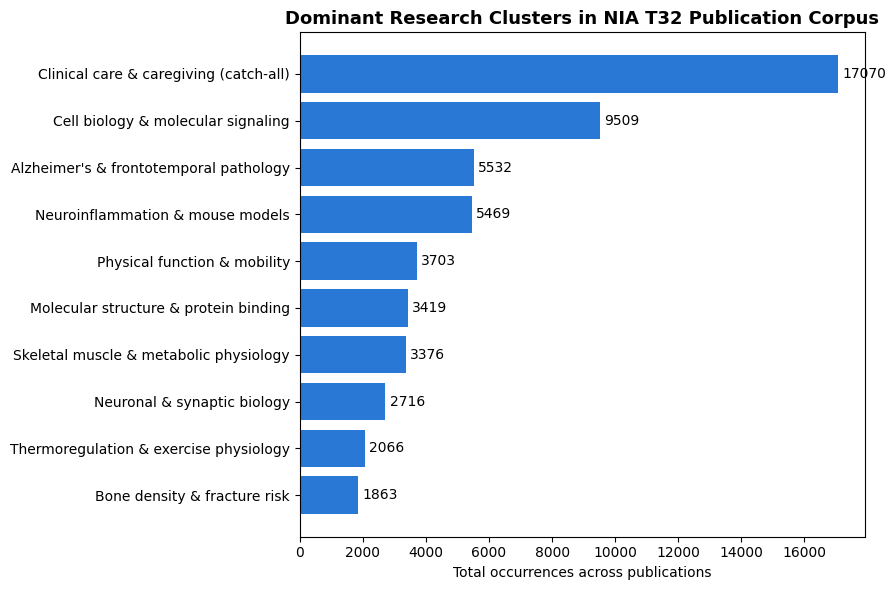

Saved: chart_dominant_clusters.png


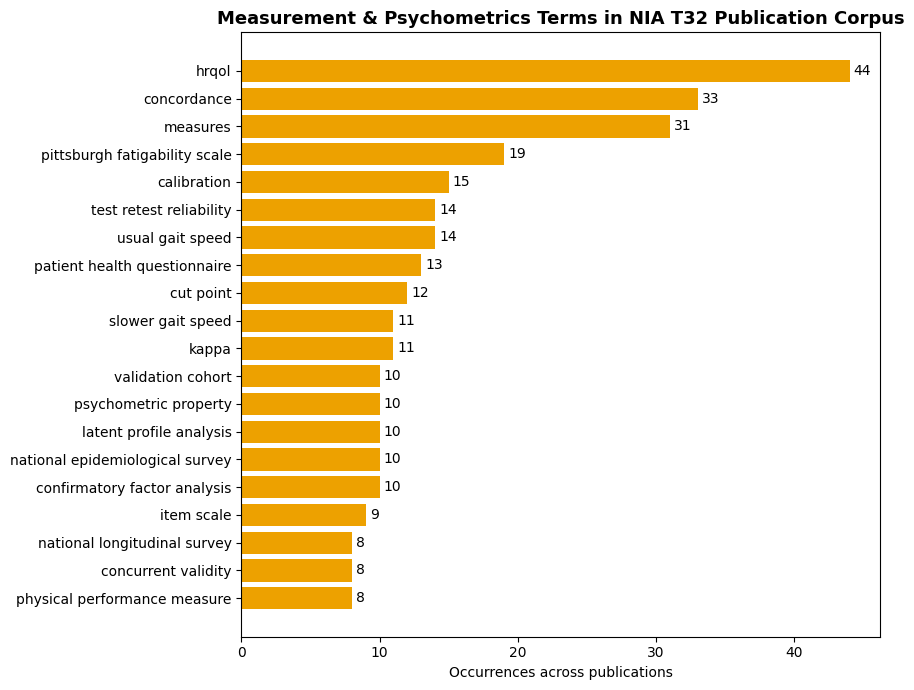

Saved: chart_measurement_terms.png


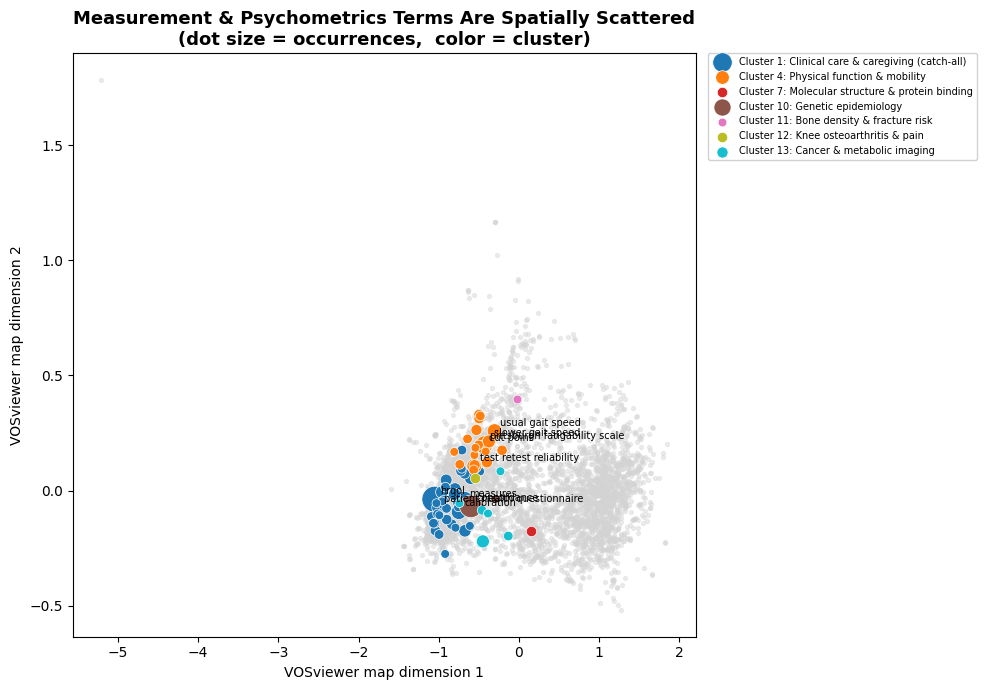

Saved: chart_measurement_terms_spatial.png

Measurement terms: 564 of 65,794 total occurrences (0.86%)
Unique measurement terms: 65

Occurrences by cluster:
                                                n_terms  total_occ
cluster cluster_name                                              
1       Clinical care & caregiving (catch-all)       34        304
4       Physical function & mobility                 20        165
10      Genetic epidemiology                          2         38
13      Cancer & metabolic imaging                    6         38
7       Molecular structure & protein binding         1          7
12      Knee osteoarthritis & pain                    1          7
11      Bone density & fracture risk                  1          5


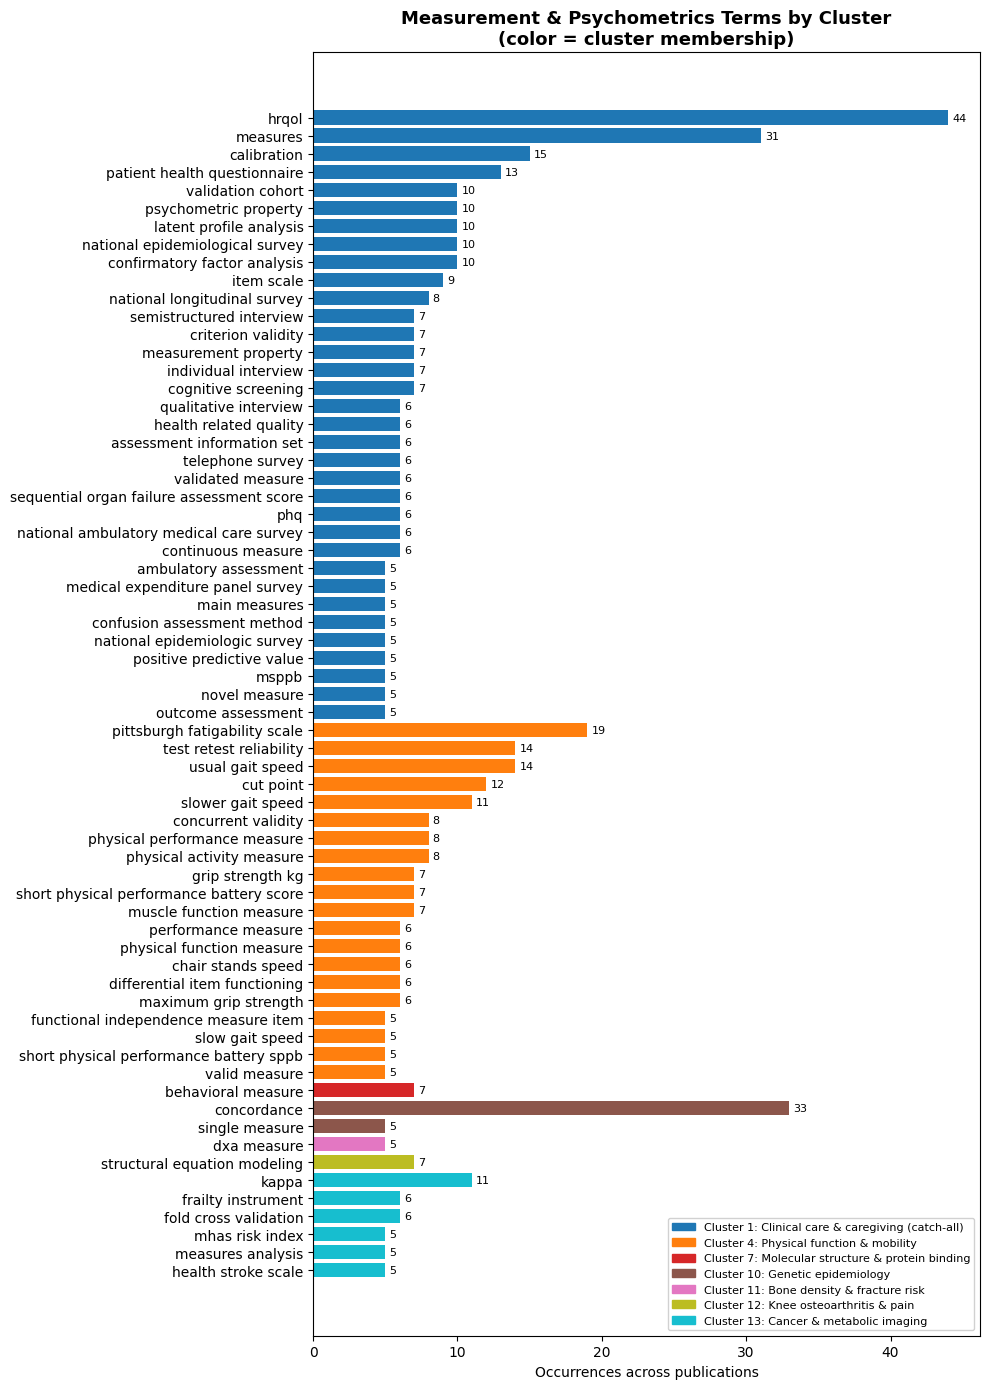

Saved: chart_measurement_terms_by_cluster.png


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ── SETTINGS ──────────────────────────────────────────────────────────────────
MAP_FILE   = "output/vosviewer_map_file_pubs.txt"
MEAS_FILE  = "output/measurement_psychometric_terms_v2.csv"
OUT_DIR    = "output"
# ─────────────────────────────────────────────────────────────────────────────

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

df      = pd.read_csv(MAP_FILE, sep="\t")
df['label'] = df['label'].astype(str)
meas_df = pd.read_csv(MEAS_FILE)

cluster_names = {
    1:  "Clinical care & caregiving (catch-all)",
    2:  "Cell biology & molecular signaling",
    3:  "Alzheimer's & frontotemporal pathology",
    4:  "Physical function & mobility",
    5:  "Neuroinflammation & mouse models",
    6:  "Skeletal muscle & metabolic physiology",
    7:  "Molecular structure & protein binding",
    8:  "Neuronal & synaptic biology",
    9:  "Thermoregulation & exercise physiology",
    10: "Genetic epidemiology",
    11: "Bone density & fracture risk",
    12: "Knee osteoarthritis & pain",
    13: "Cancer & metabolic imaging",
    14: "Immunology & vascular biology",
    15: "Cell signaling & phosphorylation",
    16: "Endocrinology & metabolic markers",
    17: "RNA biology & ALS",
    18: "Receptor pharmacology",
    19: "Ophthalmology & glaucoma",
    20: "Mitochondrial & beta-cell biology",
    21: "Growth factors & cardiac physiology",
    22: "Miscellaneous", 23: "Miscellaneous", 24: "Miscellaneous",
}

df["cluster_name"] = df["cluster"].map(cluster_names)

# ═══════════════════════════════════════════════════════════════════════════
# CHART 1: Dominant Research Clusters
# ═══════════════════════════════════════════════════════════════════════════

cluster_totals = (
    df.groupby(["cluster", "cluster_name"])["weight<Occurrences>"]
    .sum()
    .reset_index()
    .sort_values("weight<Occurrences>", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    cluster_totals["cluster_name"][::-1],
    cluster_totals["weight<Occurrences>"][::-1],
    color="#2a78d6"
)
ax.set_xlabel("Total occurrences across publications")
ax.set_title("Dominant Research Clusters in NIA T32 Publication Corpus",
             fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3, fmt="%.0f")
plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_dominant_clusters.png", dpi=150)
plt.show()
print("Saved: chart_dominant_clusters.png")


# ═══════════════════════════════════════════════════════════════════════════
# CHART 2: Measurement & Psychometrics Terms
# ═══════════════════════════════════════════════════════════════════════════

top_meas = meas_df.nlargest(20, "occurrences")

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    top_meas["term"][::-1],
    top_meas["occurrences"][::-1],
    color="#eda100"
)
ax.set_xlabel("Occurrences across publications")
ax.set_title("Measurement & Psychometrics Terms in NIA T32 Publication Corpus",
             fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3, fmt="%.0f")
plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_measurement_terms.png", dpi=150)
plt.show()
print("Saved: chart_measurement_terms.png")


# ═══════════════════════════════════════════════════════════════════════════
# CHART 3: Spatial scatter — measurement terms on VOSviewer map
# ═══════════════════════════════════════════════════════════════════════════

# Merge meas_df with x/y coordinates from the full map file
coord_cols = ["label", "x", "y"]
map_coords = df[coord_cols].rename(columns={"label": "term"})
meas_spatial = meas_df.merge(map_coords, on="term", how="left")

# Assign a color per cluster
unique_clusters = sorted(meas_spatial["cluster"].unique())
palette = plt.colormaps["tab10"].resampled(len(unique_clusters))
cluster_color_map = {c: palette(i) for i, c in enumerate(unique_clusters)}

fig, ax = plt.subplots(figsize=(10, 7))

# All terms as gray background
ax.scatter(df["x"], df["y"], s=8, color="lightgray", alpha=0.4, zorder=1)

# Measurement terms colored by cluster, sized by occurrence
for c in unique_clusters:
    subset = meas_spatial[meas_spatial["cluster"] == c]
    ax.scatter(
        subset["x"], subset["y"],
        s=subset["occurrences"] * 8,
        color=cluster_color_map[c],
        edgecolor="white", linewidth=0.5,
        label=f"Cluster {c}: {cluster_names.get(c, 'Unknown')}",
        zorder=3
    )

# Label top 10 terms by occurrence
for _, row in meas_spatial.nlargest(10, "occurrences").iterrows():
    ax.annotate(
        row["term"], (row["x"], row["y"]),
        fontsize=7, xytext=(4, 4), textcoords="offset points"
    )

ax.set_title(
    "Measurement & Psychometrics Terms Are Spatially Scattered\n(dot size = occurrences,  color = cluster)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("VOSviewer map dimension 1")
ax.set_ylabel("VOSviewer map dimension 2")
ax.legend(loc="upper left", fontsize=7, framealpha=0.9,
          bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(Path(OUT_DIR) / "chart_measurement_terms_spatial.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_measurement_terms_spatial.png")

# ── Summary stat ──────────────────────────────────────────────────────────────
total_occ = df["weight<Occurrences>"].sum()
meas_occ  = meas_df["occurrences"].sum()
print(f"\nMeasurement terms: {meas_occ:,} of {total_occ:,} total occurrences "
      f"({meas_occ/total_occ*100:.2f}%)")
print(f"Unique measurement terms: {len(meas_df)}")
print(f"\nOccurrences by cluster:")
print(
    meas_df.groupby(["cluster","cluster_name"])["occurrences"]
    .agg(["count","sum"])
    .rename(columns={"count":"n_terms","sum":"total_occ"})
    .sort_values("total_occ", ascending=False)
)

# ═══════════════════════════════════════════════════════════════════════════
# CHART 4: Measurement Terms Colored by Cluster (horizontal bar)
# ═══════════════════════════════════════════════════════════════════════════

# Sort by cluster first, then by occurrences within cluster
meas_by_cluster = meas_df.sort_values(
    ["cluster", "occurrences"], ascending=[True, False]
)

# Assign a color per cluster
unique_clusters = sorted(meas_by_cluster["cluster"].unique())
palette = plt.colormaps["tab10"].resampled(len(unique_clusters))
cluster_color_map = {c: palette(i) for i, c in enumerate(unique_clusters)}
bar_colors = meas_by_cluster["cluster"].map(cluster_color_map)

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(
    meas_by_cluster["term"],
    meas_by_cluster["occurrences"],
    color=bar_colors
)
ax.set_xlabel("Occurrences across publications")
ax.set_title(
    "Measurement & Psychometrics Terms by Cluster\n(color = cluster membership)",
    fontsize=13, fontweight="bold"
)
ax.bar_label(bars, padding=3, fmt="%.0f", fontsize=8)
ax.invert_yaxis()

# Legend showing cluster names
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=cluster_color_map[c])
    for c in unique_clusters
]
legend_labels = [
    f"Cluster {c}: {cluster_names.get(c, 'Unknown')}"
    for c in unique_clusters
]
ax.legend(
    legend_handles, legend_labels,
    loc="lower right", fontsize=8, framealpha=0.9
)

plt.tight_layout()
plt.savefig(
    Path(OUT_DIR) / "chart_measurement_terms_by_cluster.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: chart_measurement_terms_by_cluster.png")